In [ ]:
import os
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d riyaelizashaju/skin-disease-classification-image-dataset


Dataset URL: https://www.kaggle.com/datasets/riyaelizashaju/skin-disease-classification-image-dataset
License(s): unknown
 76% 128M/169M [00:00<00:00, 1.33GB/s]
100% 169M/169M [00:00<00:00, 1.15GB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("skin-disease-classification-image-dataset.zip","r") as z:
    z.extractall("skin_disease_dataset")


In [ ]:
!pip install split-folders

In [ ]:
import os

for root, dirs, files in os.walk("skin_disease_dataset"):
    print(root, len(files))


skin_disease_dataset 0
skin_disease_dataset/Split_smol 0
skin_disease_dataset/Split_smol/val 0
skin_disease_dataset/Split_smol/val/Vascular lesion 20
skin_disease_dataset/Split_smol/val/Squamous cell carcinoma 20
skin_disease_dataset/Split_smol/val/Melanoma 20
skin_disease_dataset/Split_smol/val/Tinea Ringworm Candidiasis 20
skin_disease_dataset/Split_smol/val/Actinic keratosis 20
skin_disease_dataset/Split_smol/val/Atopic Dermatitis 21
skin_disease_dataset/Split_smol/val/Dermatofibroma 20
skin_disease_dataset/Split_smol/val/Melanocytic nevus 20
skin_disease_dataset/Split_smol/val/Benign keratosis 20
skin_disease_dataset/Split_smol/train 0
skin_disease_dataset/Split_smol/train/Vascular lesion 80
skin_disease_dataset/Split_smol/train/Squamous cell carcinoma 80
skin_disease_dataset/Split_smol/train/Melanoma 80
skin_disease_dataset/Split_smol/train/Tinea Ringworm Candidiasis 56
skin_disease_dataset/Split_smol/train/Actinic keratosis 80
skin_disease_dataset/Split_smol/train/Atopic Dermatit

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Use your dataset’s actual path
train_dataset = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/train", transform=transform)
val_dataset   = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# Pretrained ResNet18
model = models.resnet18(pretrained=True)
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {running_loss/len(train_loader):.4f} "
          f"| Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {acc:.2f}%")

# Save model
torch.save(model.state_dict(), "skin_disease_model.pth")
print("✅ Model saved as skin_disease_model.pth")


Using device: cuda
Classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
Train size: 697
Val size: 181
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:01<00:00, 44.7MB/s]


Epoch [1/5] | Train Loss: 1.1199 | Val Loss: 10.6645 | Val Acc: 43.65%
Epoch [2/5] | Train Loss: 0.8567 | Val Loss: 2.1040 | Val Acc: 49.17%
Epoch [3/5] | Train Loss: 0.6702 | Val Loss: 0.8632 | Val Acc: 67.40%
Epoch [4/5] | Train Loss: 0.4157 | Val Loss: 0.9135 | Val Acc: 72.38%
Epoch [5/5] | Train Loss: 0.3627 | Val Loss: 0.9645 | Val Acc: 65.75%
✅ Model saved as skin_disease_model.pth


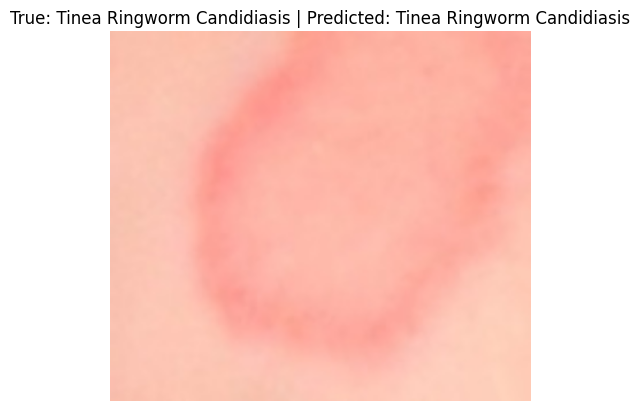

In [ ]:
import random
from PIL import Image

model.eval()
img_path, label = val_dataset.samples[random.randint(0, len(val_dataset)-1)]
img = Image.open(img_path).convert("RGB")

transform_img = transform(img).unsqueeze(0).to(device)
with torch.no_grad():
    outputs = model(transform_img)
    _, pred = torch.max(outputs, 1)

plt.imshow(img)
plt.title(f"True: {val_dataset.classes[label]} | Predicted: {val_dataset.classes[pred.item()]}")
plt.axis("off")
plt.show()


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Brightness transforms
# -----------------------------
# You can change brightness factor to test different levels
brightness_levels = [0.5, 0.8, 1.0, 1.2, 1.5]

results = {}

for b in brightness_levels:
    print(f"\nTesting with brightness factor: {b}")

    val_transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=b),   # adjust brightness
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_dataset = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/val", transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # -----------------------------
    # 3. Load trained model
    # -----------------------------
    from torchvision import models
    import torch.nn as nn

    model = models.resnet18(pretrained=False)
    num_classes = len(val_dataset.classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load("skin_disease_model.pth", map_location=device))
    model = model.to(device)
    model.eval()

    # -----------------------------
    # 4. Evaluate accuracy
    # -----------------------------
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy on brightness {b}: {acc:.2f}%")
    results[b] = acc

print("\n✅ Summary of accuracies on different brightness levels:")
for b, a in results.items():
    print(f"Brightness {b}: {a:.2f}%")


Using device: cuda

Testing with brightness factor: 0.5


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Accuracy on brightness 0.5: 52.49%

Testing with brightness factor: 0.8
Accuracy on brightness 0.8: 41.44%

Testing with brightness factor: 1.0
Accuracy on brightness 1.0: 41.99%

Testing with brightness factor: 1.2
Accuracy on brightness 1.2: 36.46%

Testing with brightness factor: 1.5
Accuracy on brightness 1.5: 40.33%

✅ Summary of accuracies on different brightness levels:
Brightness 0.5: 52.49%
Brightness 0.8: 41.44%
Brightness 1.0: 41.99%
Brightness 1.2: 36.46%
Brightness 1.5: 40.33%


Using device: cuda

🔆 Testing with brightness factor: 0.5


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 51.93%
  Actinic keratosis: 35.00%
  Atopic Dermatitis: 90.48%
  Benign keratosis: 45.00%
  Dermatofibroma: 10.00%
  Melanocytic nevus: 45.00%
  Melanoma: 45.00%
  Squamous cell carcinoma: 25.00%
  Tinea Ringworm Candidiasis: 90.00%
  Vascular lesion: 80.00%

🔆 Testing with brightness factor: 0.8


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 37.02%
  Actinic keratosis: 10.00%
  Atopic Dermatitis: 61.90%
  Benign keratosis: 20.00%
  Dermatofibroma: 15.00%
  Melanocytic nevus: 25.00%
  Melanoma: 30.00%
  Squamous cell carcinoma: 25.00%
  Tinea Ringworm Candidiasis: 95.00%
  Vascular lesion: 50.00%

🔆 Testing with brightness factor: 1.0


...

Overall accuracy: 39.78%
  Actinic keratosis: 10.00%
  Atopic Dermatitis: 71.43%
  Benign keratosis: 20.00%
  Dermatofibroma: 5.00%
  Melanocytic nevus: 25.00%
  Melanoma: 50.00%
  Squamous cell carcinoma: 15.00%
  Tinea Ringworm Candidiasis: 95.00%
  Vascular lesion: 65.00%

🔆 Testing with brightness factor: 1.2


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 35.91%
  Actinic keratosis: 15.00%
  Atopic Dermatitis: 71.43%
  Benign keratosis: 25.00%
  Dermatofibroma: 10.00%
  Melanocytic nevus: 25.00%
  Melanoma: 20.00%
  Squamous cell carcinoma: 15.00%
  Tinea Ringworm Candidiasis: 90.00%
  Vascular lesion: 50.00%

🔆 Testing with brightness factor: 1.5


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Overall accuracy: 37.02%
  Actinic keratosis: 10.00%
  Atopic Dermatitis: 80.95%
  Benign keratosis: 25.00%
  Dermatofibroma: 10.00%
  Melanocytic nevus: 30.00%
  Melanoma: 20.00%
  Squamous cell carcinoma: 10.00%
  Tinea Ringworm Candidiasis: 100.00%
  Vascular lesion: 45.00%

✅ Summary of overall accuracies:
Brightness 0.5: 51.93%
Brightness 0.8: 37.02%
Brightness 1.0: 39.78%
Brightness 1.2: 35.91%
Brightness 1.5: 37.02%


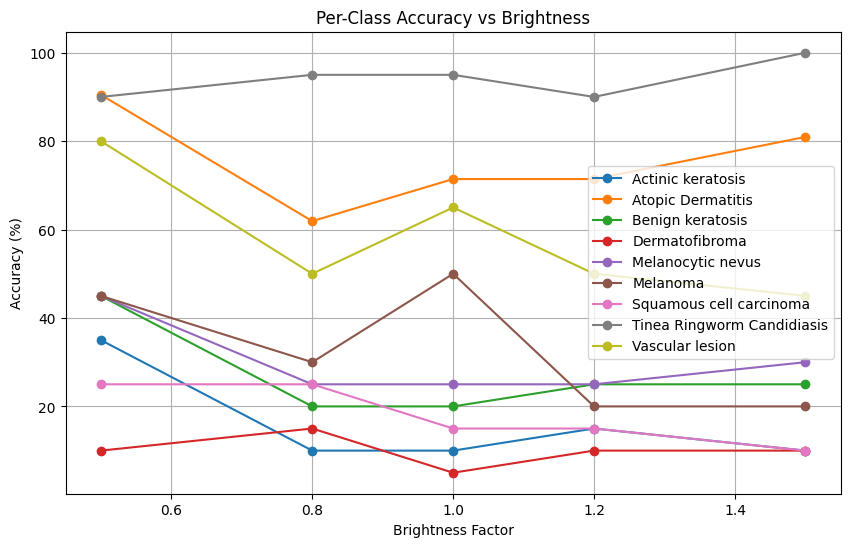

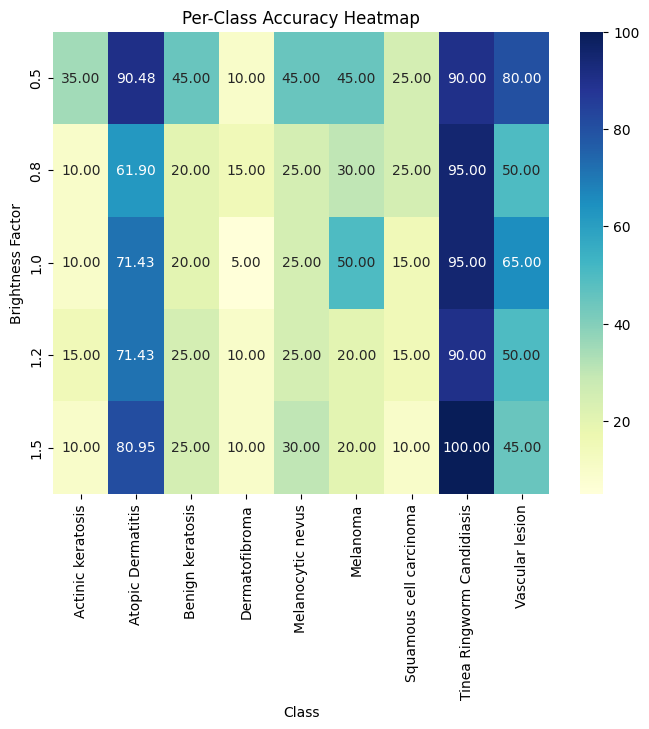

In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Brightness transforms
# -----------------------------
brightness_levels = [0.5, 0.8, 1.0, 1.2, 1.5]

# Store results
overall_results = {}
per_class_results = {}

# -----------------------------
# 3. Loop through brightness levels
# -----------------------------
for b in brightness_levels:
    print(f"\n🔆 Testing with brightness factor: {b}")

    val_transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=b),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_dataset = datasets.ImageFolder(root="skin_disease_dataset/Split_smol/val", transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    class_names = val_dataset.classes
    num_classes = len(class_names)

    # -----------------------------
    # 4. Load trained model
    # -----------------------------
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load("skin_disease_model.pth", map_location=device))
    model = model.to(device)
    model.eval()

    # -----------------------------
    # 5. Evaluate per-class
    # -----------------------------
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))

    # Per-class accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_results[b] = class_acc
    overall_acc = (all_preds == all_labels).mean() * 100
    overall_results[b] = overall_acc

    print(f"Overall accuracy: {overall_acc:.2f}%")
    for i, acc in enumerate(class_acc):
        print(f"  {class_names[i]}: {acc*100:.2f}%")

# -----------------------------
# 6. Summary print
# -----------------------------
print("\n✅ Summary of overall accuracies:")
for b, acc in overall_results.items():
    print(f"Brightness {b}: {acc:.2f}%")

# -----------------------------
# 7. Visualization
# -----------------------------
# Per-class accuracy vs brightness (line plot)
plt.figure(figsize=(10,6))
for i, cls in enumerate(class_names):
    accs = [per_class_results[b][i]*100 for b in brightness_levels]
    plt.plot(brightness_levels, accs, marker='o', label=cls)

plt.xlabel("Brightness Factor")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy vs Brightness")
plt.legend()
plt.grid(True)
plt.show()

# Heatmap (optional)
plt.figure(figsize=(8,6))
heatmap_data = np.array([per_class_results[b]*100 for b in brightness_levels])
sns.heatmap(heatmap_data, annot=True, xticklabels=class_names, yticklabels=brightness_levels, fmt=".2f", cmap="YlGnBu")
plt.xlabel("Class")
plt.ylabel("Brightness Factor")
plt.title("Per-Class Accuracy Heatmap")
plt.show()


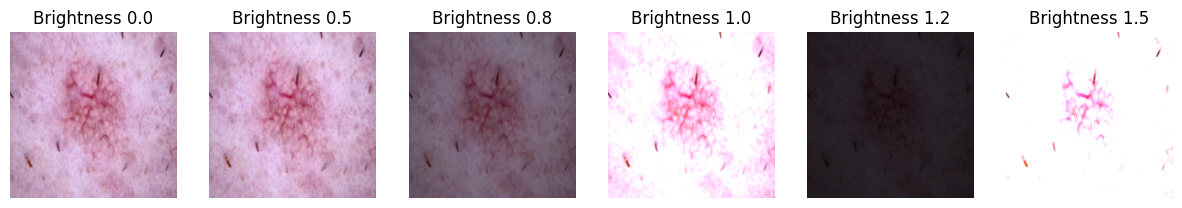

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import random

# Pick a random image from validation set
val_dataset_path = "skin_disease_dataset/Split_smol/val"
classes = sorted(os.listdir(val_dataset_path))
sample_class = random.choice(classes)
sample_image_path = random.choice(os.listdir(f"{val_dataset_path}/{sample_class}"))
img_path = f"{val_dataset_path}/{sample_class}/{sample_image_path}"

# Load image
img = Image.open(img_path).convert("RGB")

# Brightness levels to visualize
brightness_levels = [0.0,0.5, 0.8, 1.0, 1.2, 1.5]

plt.figure(figsize=(15,5))

for i, b in enumerate(brightness_levels):
    transform_b = transforms.Compose([
        transforms.ColorJitter(brightness=b),
        transforms.Resize((224,224))
    ])
    img_b = transform_b(img)

    plt.subplot(1, len(brightness_levels), i+1)
    plt.imshow(img_b)
    plt.title(f"Brightness {b}")
    plt.axis("off")

plt.show()
